This script is just for seeing which ingredients Model 22 is predicting on my own dataset.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import textwrap

OWN_DATASET_DIR = Path("/content/drive/MyDrive/Speciale/Own test data set")

PREPARED_DATASET_DIR = Path(
    "/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset"
)

MODEL22_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator"
)

MODEL22_RESULTS_CSV = OWN_DATASET_DIR / "model_22_own_test_predictions.csv"

METADATA_CSV = PREPARED_DATASET_DIR / "dish_carb_mass_ingredients_split_metadata.csv"

print("Model 22 results:", MODEL22_RESULTS_CSV)
print("Metadata:", METADATA_CSV)

print("Model 22 results exists:", MODEL22_RESULTS_CSV.exists())
print("Metadata exists:", METADATA_CSV.exists())

Model 22 results: /content/drive/MyDrive/Speciale/Own test data set/model_22_own_test_predictions.csv
Metadata: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
Model 22 results exists: True
Metadata exists: True


Loading model 22 predictions and ingredients

In [4]:
model22_df = pd.read_csv(MODEL22_RESULTS_CSV)
metadata_df = pd.read_csv(METADATA_CSV)

print("Model 22 results shape:", model22_df.shape)
print("Metadata shape:", metadata_df.shape)

# Ingredient prediction
ingredient_pred_cols = [
    col for col in model22_df.columns
    if col.startswith("ingredient_pred_")
]

ingredient_pred_cols = sorted(ingredient_pred_cols)

print("Number of ingredient prediction columns:", len(ingredient_pred_cols))

ingredient_cols = [
    col for col in metadata_df.columns
    if col.startswith("ingr_")
]

ingredient_cols = sorted(ingredient_cols)

ingredient_names = [
    col.replace("ingr_", "").replace("_", " ")
    for col in ingredient_cols
]

print("Number of metadata ingredient columns:", len(ingredient_names))

if len(ingredient_pred_cols) != len(ingredient_names):
    raise ValueError(
        f"Ingredient mismatch: "
        f"{len(ingredient_pred_cols)} prediction columns but "
        f"{len(ingredient_names)} metadata ingredient columns."
    )

display(model22_df.head())

Model 22 results shape: (62, 204)
Metadata shape: (3262, 205)
Number of ingredient prediction columns: 198
Number of metadata ingredient columns: 198


,dish_id,rgb_path,image_name,predicted_carb_g,model3_v3_rgb_pred,model22_predicted_carb_g,ingredient_pred_000,ingredient_pred_001,ingredient_pred_002,ingredient_pred_003,...,ingredient_pred_188,ingredient_pred_189,ingredient_pred_190,ingredient_pred_191,ingredient_pred_192,ingredient_pred_193,ingredient_pred_194,ingredient_pred_195,ingredient_pred_196,ingredient_pred_197
0,Dish_0001,/content/drive/MyDrive/Speciale/Own test data ...,IMG_0130.jpeg,50.170930,50.170930,51.370712,0.000636,0.012316,0.000204,0.000036,...,0.000058,2.147783e-04,4.831541e-06,0.002484,1.048391e-07,2.514215e-08,0.000626,0.000089,6.239048e-05,0.000035
1,Dish_0002,/content/drive/MyDrive/Speciale/Own test data ...,IMG_0139.jpeg,36.032814,36.032814,38.661514,0.001442,0.093997,0.005921,0.013159,...,0.010005,3.158935e-03,3.425601e-04,0.016377,4.978375e-05,7.960341e-06,0.015622,0.001321,4.192667e-03,0.003094
2,Dish_0003,/content/drive/MyDrive/Speciale/Own test data ...,IMG_0148.jpg,3.953832,3.953832,4.976609,0.000019,0.000023,0.000008,0.000003,...,0.000013,3.582616e-07,6.304961e-07,0.000043,7.099636e-07,8.313129e-11,0.000013,0.000063,2.128502e-04,0.000007
3,Dish_0004,/content/drive/MyDrive/Speciale/Own test data ...,IMG_0158.jpg,18.204813,18.204813,17.551285,0.138613,0.034186,0.000105,0.000023,...,0.000397,4.466693e-05,1.448837e-06,0.000690,1.540001e-06,4.581423e-07,0.000041,0.008118,7.259287e-04,0.000032
4,Dish_0005,/content/drive/MyDrive/Speciale/Own test data ...,IMG_0192.jpg,36.296500,36.296500,38.521500,0.000134,0.000470,0.000819,0.003325,...,0.291125,2.955556e-07,2.540712e-05,0.012820,2.130545e-04,1.949846e-07,0.017570,0.000010,1.335352e-07,0.013085


In [20]:
OWN_GROUND_TRUTH_XLSX = OWN_DATASET_DIR / "Performance on own dataset.xlsx"

print("Ground truth Excel:", OWN_GROUND_TRUTH_XLSX)
print("Exists:", OWN_GROUND_TRUTH_XLSX.exists())

actual_df = pd.read_excel(OWN_GROUND_TRUTH_XLSX)

print("Excel columns:")
print(actual_df.columns.tolist())

display(actual_df.head())

Ground truth Excel: /content/drive/MyDrive/Speciale/Own test data set/Performance on own dataset.xlsx
Exists: True
Excel columns:
['Dish_ID', 'OPEN AI ESTIMATION', 'CLAUDE ESTIMATION (HAIKU 4.5)', 'GEMINI ESTIMATION ', 'Model 3 V3 performance', 'Model 22 performance', 'Model 24 performance', 'Model 3 V5 (data aug)', 'ACTUAL']


,Dish_ID,OPEN AI ESTIMATION,CLAUDE ESTIMATION (HAIKU 4.5),GEMINI ESTIMATION,Model 3 V3 performance,Model 22 performance,Model 24 performance,Model 3 V5 (data aug),ACTUAL
0,Dish_0001,40,28.5,35.0,50.17,51.4,49.090000,27.35,67.60
1,Dish_0002,45,42.5,42.0,36.03,38.7,40.437500,25.62,71.72
2,Dish_0003,25,12.5,24.0,3.95,5.0,20.218750,4.67,35.56
3,Dish_0004,40,45.0,35.0,18.20,17.6,14.742188,16.62,45.48
4,Dish_0005,18,2.5,35.0,36.30,38.5,34.937500,20.24,35.50


In [25]:
actual_df.columns = actual_df.columns.str.strip()
model22_df.columns = model22_df.columns.str.strip()

if "Dish_ID" not in actual_df.columns:
    raise ValueError(
        f"Could not find column 'Dish_ID'. Found columns: {actual_df.columns.tolist()}"
    )

if "ACTUAL" not in actual_df.columns:
    raise ValueError(
        f"Could not find column 'ACTUAL'. Found columns: {actual_df.columns.tolist()}"
    )

actual_df["Dish_ID"] = actual_df["Dish_ID"].astype(str)
model22_df["dish_id"] = model22_df["dish_id"].astype(str)

model22_df = model22_df.merge(
    actual_df[["Dish_ID", "ACTUAL"]],
    left_on="dish_id",
    right_on="Dish_ID",
    how="left"
)

model22_df = model22_df.rename(columns={"ACTUAL": "actual_carb_g"})

model22_df = model22_df.drop(columns=["Dish_ID"])

print("Missing actual values after merge:", model22_df["actual_carb_g"].isna().sum())

display(
    model22_df[
        ["dish_id", "image_name", "model22_predicted_carb_g", "actual_carb_g"]
    ].head()
)

Missing actual values after merge: 0


,dish_id,image_name,model22_predicted_carb_g,actual_carb_g
0,Dish_0001,IMG_0130.jpeg,51.370712,67.60
1,Dish_0002,IMG_0139.jpeg,38.661514,71.72
2,Dish_0003,IMG_0148.jpg,4.976609,35.56
3,Dish_0004,IMG_0158.jpg,17.551285,45.48
4,Dish_0005,IMG_0192.jpg,38.521500,35.50


Choosing dishes to show

In [26]:
SELECTED_DISHES = ["Dish_0025", "Dish_0015", "Dish_0056"]

TOP_K_INGREDIENTS = 6
PROB_THRESHOLD = 0.30

SAVE_FIGURE = False
SAVE_PATH = OWN_DATASET_DIR / "model22_own_dataset_ingredient_examples.png"

In [27]:
def get_row_from_selection(selection):
    """
    Allows SELECTED_DISHES to contain either:
    - row indices, e.g. [0, 1, 2]
    - dish_id values, e.g. ["dish_001", "dish_002", "dish_003"]
    """

    if isinstance(selection, int):
        return model22_df.iloc[selection]

    match = model22_df[
        model22_df["dish_id"].astype(str) == str(selection)
    ]

    if len(match) == 0:
        raise ValueError(f"Could not find selected dish: {selection}")

    return match.iloc[0]


def get_top_predicted_ingredients(row, top_k=TOP_K_INGREDIENTS, threshold=PROB_THRESHOLD):
    probs = row[ingredient_pred_cols].astype(float).values

    top_indices = np.argsort(probs)[::-1][:top_k]

    selected = []

    for idx in top_indices:
        prob = probs[idx]

        if prob >= threshold:
            selected.append((ingredient_names[idx], prob))

    if len(selected) == 0:
        selected = [
            (ingredient_names[idx], probs[idx])
            for idx in top_indices
        ]

    return selected


def format_ingredient_text(ingredients):
    lines = [
        f"{name}: {prob:.2f}"
        for name, prob in ingredients
    ]

    return "\n".join(lines)

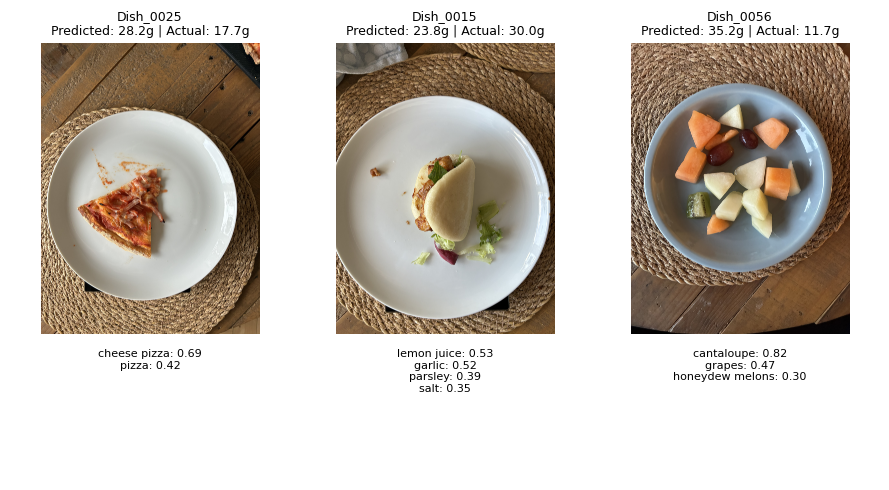

In [28]:
selected_rows = [get_row_from_selection(x) for x in SELECTED_DISHES]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(9, 5.0),
    gridspec_kw={"height_ratios": [3.0, 1.35]}
)

for col, row in enumerate(selected_rows):
    img = Image.open(row["rgb_path"]).convert("RGB")

    axes[0, col].imshow(img)
    axes[0, col].axis("off")

    title = (
        f"{row['dish_id']}\n"
        f"Predicted: {row['model22_predicted_carb_g']:.1f}g"
        f" | Actual: {row['actual_carb_g']:.1f}g"
    )

    axes[0, col].set_title(title, fontsize=9)

    top_ingredients = get_top_predicted_ingredients(row)
    ingredient_text = format_ingredient_text(top_ingredients)

    axes[1, col].axis("off")
    axes[1, col].text(
        0.5,
        1.0,
        ingredient_text,
        ha="center",
        va="top",
        fontsize=8
    )

plt.tight_layout()

if SAVE_FIGURE:
    plt.savefig(SAVE_PATH, dpi=300, bbox_inches="tight")
    print("Saved figure to:", SAVE_PATH)

plt.show()

Showing avaliable dishes

In [11]:
available_dishes = model22_df[
    ["dish_id", "image_name", "rgb_path", "model22_predicted_carb_g"]
].copy()

available_dishes = available_dishes.reset_index().rename(columns={"index": "row_index"})

display(available_dishes)

,row_index,dish_id,image_name,rgb_path,model22_predicted_carb_g
0,0,Dish_0001,IMG_0130.jpeg,/content/drive/MyDrive/Speciale/Own test data ...,51.370712
1,1,Dish_0002,IMG_0139.jpeg,/content/drive/MyDrive/Speciale/Own test data ...,38.661514
2,2,Dish_0003,IMG_0148.jpg,/content/drive/MyDrive/Speciale/Own test data ...,4.976609
3,3,Dish_0004,IMG_0158.jpg,/content/drive/MyDrive/Speciale/Own test data ...,17.551285
4,4,Dish_0005,IMG_0192.jpg,/content/drive/MyDrive/Speciale/Own test data ...,38.521500
...,...,...,...,...,...
57,57,Dish_0058,IMG_0354.jpg,/content/drive/MyDrive/Speciale/Own test data ...,28.298128
58,58,Dish_0059,IMG_0355.jpg,/content/drive/MyDrive/Speciale/Own test data ...,89.835990
59,59,Dish_0060,IMG_0356.jpg,/content/drive/MyDrive/Speciale/Own test data ...,104.978590
60,60,Dish_0061,IMG_0357.jpg,/content/drive/MyDrive/Speciale/Own test data ...,43.698723
